In [ ]:
import numpy as np
import scipy.sparse as sp
from scipy.sparse.linalg import spsolve
from tqdm import tqdm

# Parameters
L  = 1.985      # length of the domain - size of gravimetric cuboidal specimen
Nx = 1001      # number of spatial steps
dx = L / (Nx - 1) 
dt = 2.4e-3
Nt = 200000

D0 = np.exp(-7.595309)  # initial diffusivity
a = -53.020999
b = 74.417462
c = -8.636166
d = 6.457968

lbc_val = 0.444  # same as that used for/from the X-ray experiment simulation. 

# Spatial grid
x = np.linspace(-1 - 2*dx, 1 + 2*dx, Nx+4)
mask = np.ones(len(x), dtype=bool)
mask[:2] = mask[-2:] = False
K = np.arange(0, Nx+4)
Km1 = np.roll(K, 1)
Km2 = np.roll(K, 2)
Kp1 = np.roll(K, -1)
Kp2 = np.roll(K, -2)

# Arrays to store results
S_array = np.empty([Nt, Nx])       # for the solution
residual_array = np.empty(Nt)            # for the residuals
residual_max_array = np.empty([Nt, Nx])  

simulation_times = np.linspace(0, Nt * dt, Nt)

# ───────────────────  HELPERS  ─────────────────── #

def diffusion(S, D0, a, b, c, d):
    return D0 * np.exp(a*S**4 + b*S**3 + c*S**2 + d*S)

def applyBC(S, lbc_value):
    S[0:3] = lbc_value          # Dirichlet at x = 0 
    S[-1]  = S[-3]              # zero-gradient at x = L 
    S[-2]  = S[-3]


def setup_btcs_matrix_sparse(Nx, D, dx, dt, fmt="csc"):
    """
    Assemble the (Nx+4)×(Nx+4) BTCS matrix in CSC/CSR format.
    """
    alpha = dt / dx**2
    N     = Nx + 4               

    main  = np.ones(N)
    lower = np.zeros(N-1)
    upper = np.zeros(N-1)

    # vectorised interior coefficients (i = 2 … N-3)
    Dm = 0.5*(D[1:-3] + D[2:-2])   # D_{i-1/2}
    Dp = 0.5*(D[2:-2] + D[3:-1])   # D_{i+1/2}

    main [2:-2]  = 1 + alpha*(Dm + Dp)
    lower[1:-2]  = -alpha*Dm
    upper[2:-1]  = -alpha*Dp

    A = sp.diags([lower, main, upper], offsets=[-1, 0, 1], format=fmt)
    return A

# ───────────────────  TIME-STEPPING WITH PICARD ITERATION  ─────────────────── #

# Picard iteration parameters
PICARD_TOL      = 1e-8     # convergence tolerance on ||S_iter^{k+1} - S_iter^{k}||
PICARD_MAX_ITER = 50       # safety cap
PICARD_NORM     = "L2"     # "L2"

# Initial condition and BC
S = np.zeros_like(x)
applyBC(S, lbc_val)

# Diagnostics for Picard performance
picard_iters_per_step = np.zeros(Nt, dtype=int)
picard_final_delta    = np.zeros(Nt)

for n in tqdm(range(Nt)):
    # rhs is θⁿ (frozen at the start of this time step) — never updated inside the iteration
    rhs = S.copy()

    # Initial guess for θⁿ⁺¹ at iteration k=0: use θⁿ itself
    S_iter = S.copy()

    converged = False
    for k in range(PICARD_MAX_ITER):
        # Evaluate D at the current Picard iterate (not at θⁿ)
        D_iter = diffusion(S_iter, D0, a, b, c, d)

        # Assemble matrix using D_iter
        A = setup_btcs_matrix_sparse(Nx, D_iter, dx, dt, fmt="csc")

        # Solve A · S_new = θⁿ  (RHS is always θⁿ, not S_iter)
        S_new = spsolve(A, rhs)

        # Re-impose BC on the new iterate before checking convergence
        # (so BC ghost points don't dominate the norm)
        applyBC(S_new, lbc_value=lbc_val)

        # Convergence check on the change between Picard iterates
        if PICARD_NORM == "L2":
            delta = np.linalg.norm(S_new - S_iter) / max(np.linalg.norm(S_iter), 1e-30)
        else:  # Linf
            denom = max(np.max(np.abs(S_iter)), 1e-30)
            delta = np.max(np.abs(S_new - S_iter)) / denom

        S_iter = S_new

        if delta < PICARD_TOL:
            converged = True
            break

    if not converged:
        print(f"[warning] Picard did not converge at step {n}: delta = {delta:.3e}")

    # Record diagnostics
    picard_iters_per_step[n] = k + 1
    picard_final_delta[n]    = delta

    # Linear-solve residual at the converged iterate (optional)
    residual = A @ S_iter - rhs
    residual_array[n]        = np.linalg.norm(residual)
    residual_max_array[n, :] = residual[mask]

    # Advance time step
    S = S_iter
    S_array[n, :] = S[mask]

# output
x_FDM = np.linspace(0, L, Nx)
t_FDM = np.linspace(0, Nt*dt, Nt)
print("Residual array shape:", residual_array.shape)
print("Last residual:", residual_array[-1])
print(f"Picard iterations: mean={picard_iters_per_step.mean():.2f}, "
      f"max={picard_iters_per_step.max()}, "
      f"min={picard_iters_per_step.min()}")
print(f"Final Picard delta: max={picard_final_delta.max():.3e}, "
      f"mean={picard_final_delta.mean():.3e}")

100%|██████████| 200000/200000 [03:07<00:00, 1068.13it/s]

Residual array shape: (200000,)
Last residual: 4.211428588337106e-13
Picard iterations: mean=1.64, max=32, min=1
Final Picard delta: max=1.000e-08, mean=1.109e-09


In [2]:
import os
current_dir = os.getcwd()
np.save(os.path.join(current_dir, "MS_FDM_semilog_quartic_saturation_fixed_pt.npy"), S_array)

np.save(os.path.join(current_dir, "MS_FDM_semilog_quartic_residual_fixed_pt.npy"), residual_array)

In [3]:
x_FDM = np.linspace(0,L,Nx)
t_FDM = np.linspace(0,Nt*dt,Nt)
T,X = np.meshgrid(t_FDM,x_FDM)
S_dat = S_array.T.reshape(-1,1)
X_dat = X.reshape(-1,1)
T_dat = T.reshape(-1,1)
data_size = X_dat.shape[0]
mass_data = np.mean(S_array.T,axis=0)
print(mass_data.shape)

(200000,)


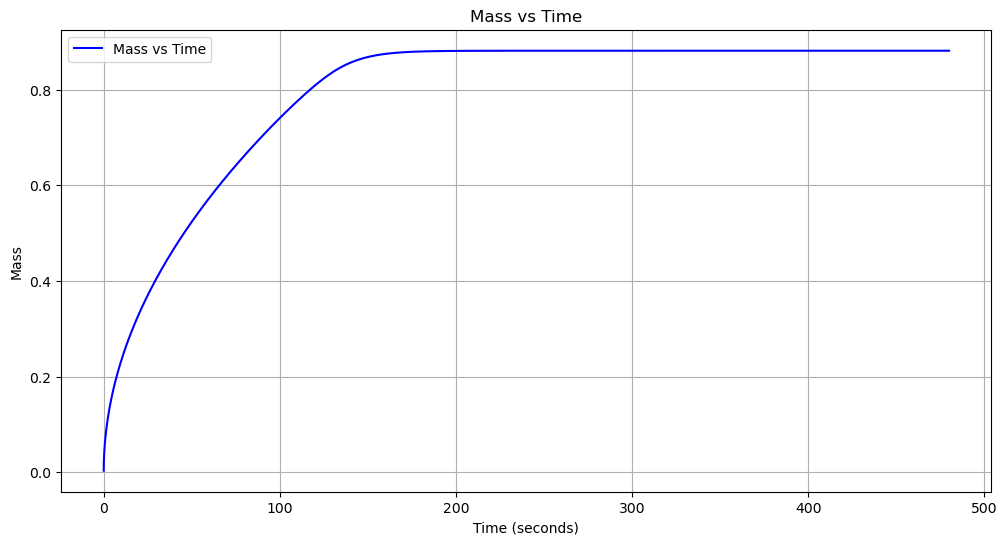

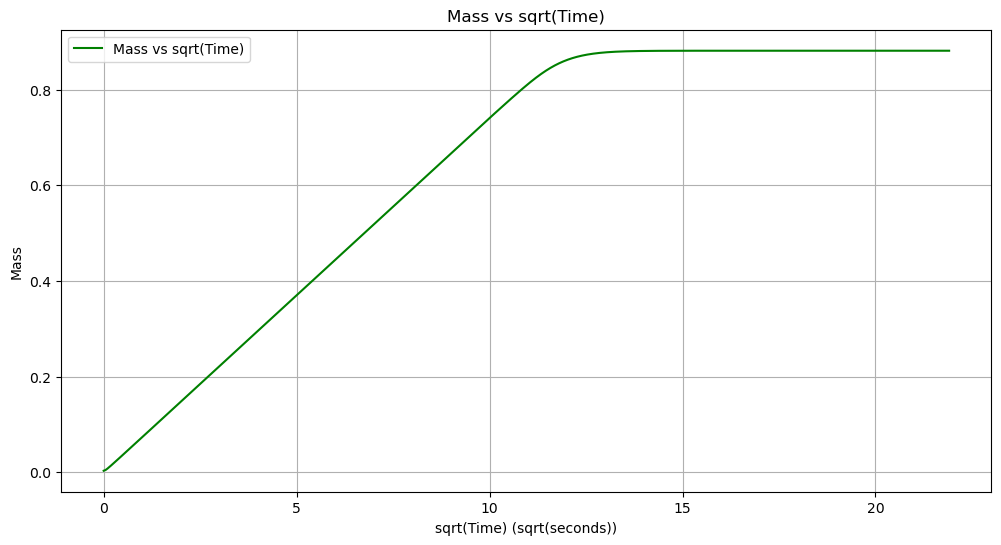

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

#S_array is the saturation array of shape (Nt, Nx)
# Time array
time_array = np.arange(0, Nt) * dt  # Nt: Number of time steps, dt: Time step size

# Spatial header array
header_array = np.arange(0, Nx) * dx  # Nx: Number of spatial points, dx: Spatial resolution

# Calculate the mass at each time step (integral of saturation over space)
# Use the trapezoidal rule to approximate the integral
mass_array = np.trapz(S_array, header_array, axis=1)  # Integral along spatial axis

# Create the square root of time array
sqrt_time_array = np.sqrt(time_array)

# Plot Mass vs Time
plt.figure(figsize=(12, 6))
plt.plot(time_array, mass_array, label="Mass vs Time", color='blue')
plt.xlabel("Time (min)")
plt.ylabel("Mass")
plt.title("Mass vs Time")
plt.grid()
plt.legend()
plt.show()

# Plot Mass vs sqrt(Time)
plt.figure(figsize=(12, 6))
plt.plot(sqrt_time_array, mass_array, label="Mass vs sqrt(Time)", color='green')
plt.xlabel("sqrt(Time) (sqrt(min))")
plt.ylabel("Mass")
plt.title("Mass vs sqrt(Time)")
plt.grid()
plt.legend()
plt.show()


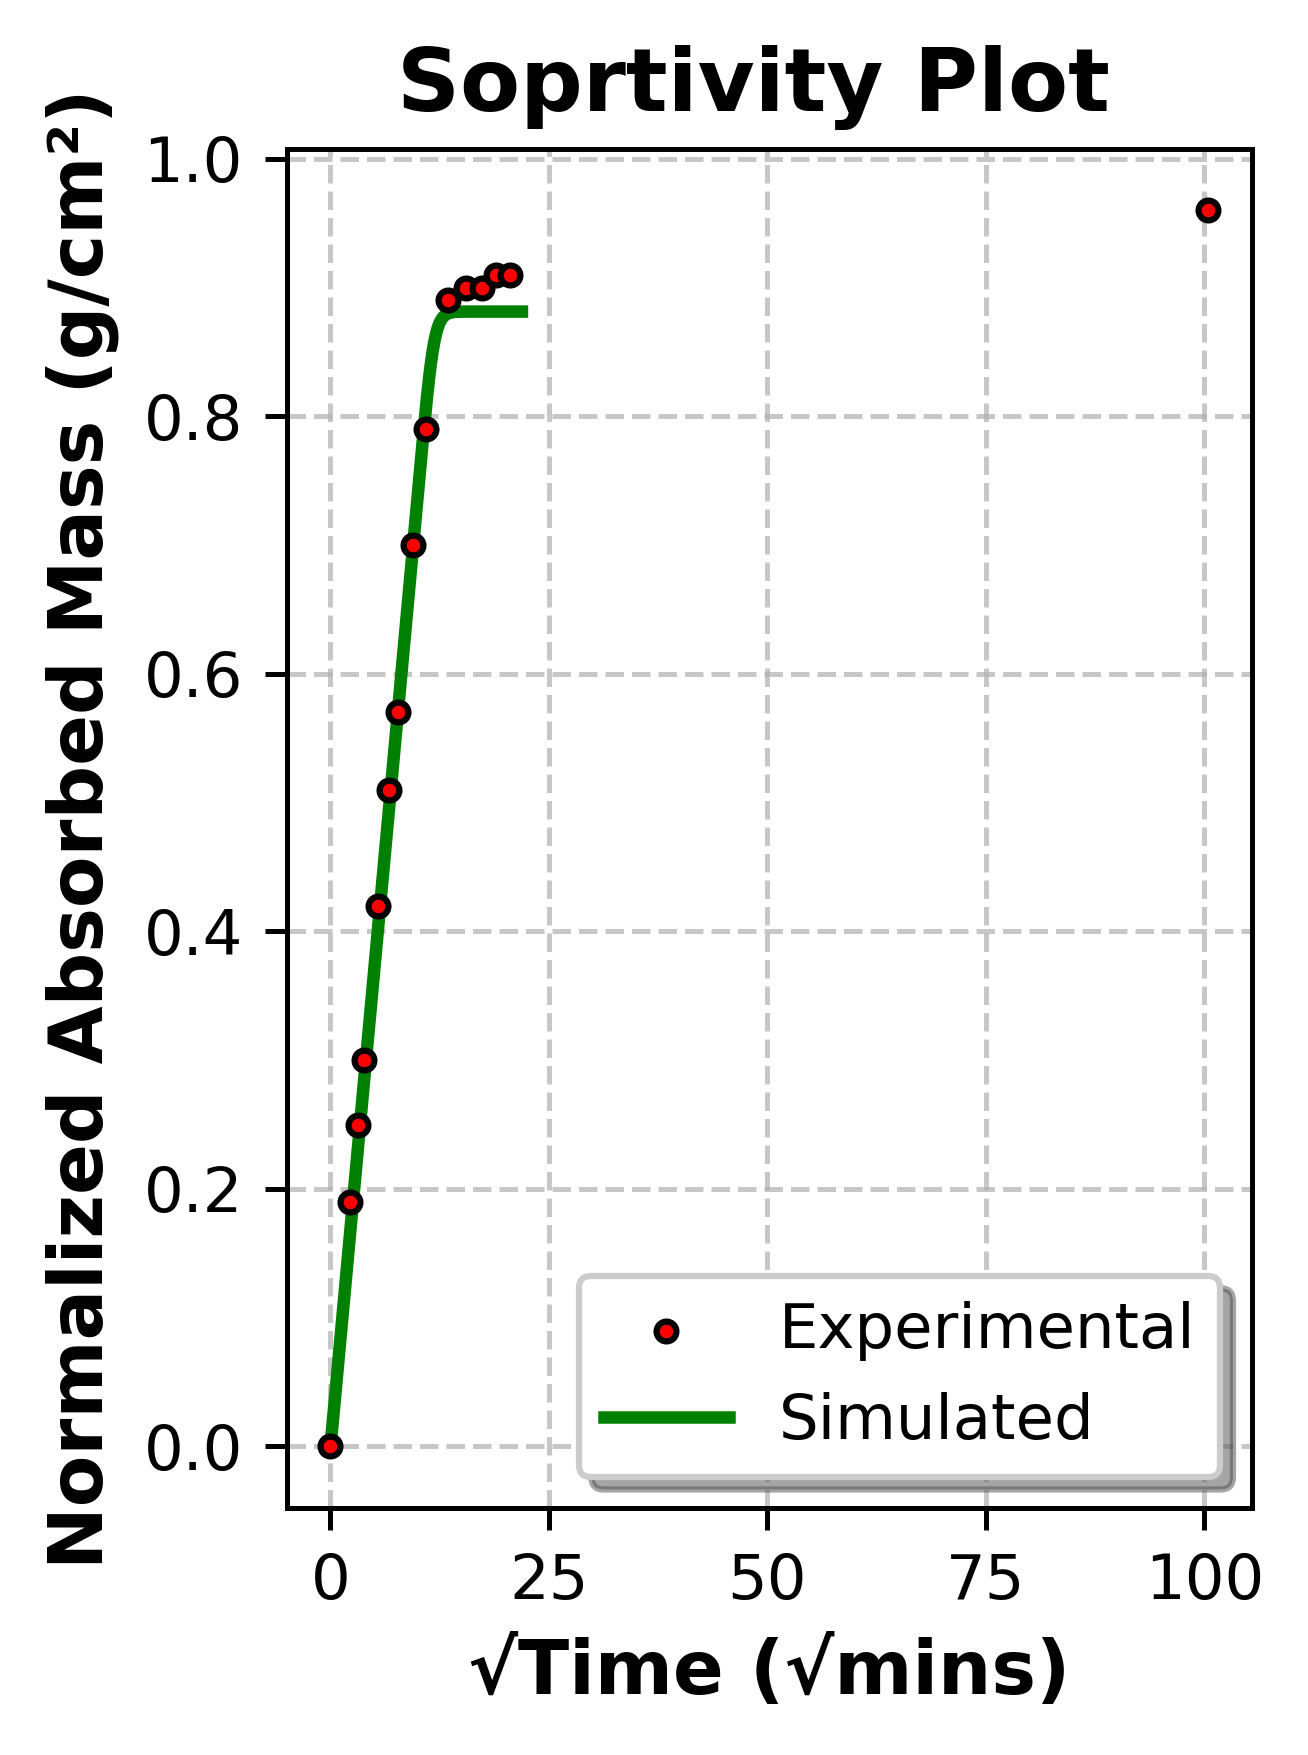

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Assume `S_array` is the saturation array of shape (Nt, Nx)
# Time array
time_array = np.arange(0, Nt) * dt  # Nt: Number of time steps, dt: Time step size

# Spatial header array
header_array = np.arange(0, Nx) * dx  # Nx: Number of spatial points, dx: Spatial resolution

# Calculate the mass at each time step (integral of saturation over space)
# Use the trapezoidal rule to approximate the integral
mass_array = np.trapz(S_array, header_array, axis=1)  # Integral along spatial axis

# Create the square root of time array
sqrt_time_array = np.sqrt(time_array)

# Experimental simulated sorptivity points
sqrt_time_new = np.array([0.00, 2.24, 3.16, 3.87, 5.48, 6.71, 7.75, 9.49, 10.95, 13.42, 15.49, 17.32, 18.97, 20.49, 100.40])
mass_new_1 = np.array([0.00, 0.19, 0.25, 0.30, 0.42, 0.51, 0.57, 0.70, 0.79, 0.89, 0.90, 0.90, 0.91, 0.91, 0.96])

# Plot Mass vs sqrt(Time)
plt.figure(figsize=(3, 4), dpi=450)

# Plot the simulated mass curve

# Add experimental sorptivity points
plt.scatter(
    sqrt_time_new, 
    mass_new_1, 
    color='red', 
    edgecolor='black', 
    label="Experimental", 
    zorder=5, 
    s=10
)

plt.plot(
    sqrt_time_array, 
    mass_array, 
    label="Simulated", 
    color='green', 
    linewidth=2
)

# Add labels and title
plt.xlabel("√Time (√mins)", fontsize=12, weight='bold')
plt.ylabel("Normalized Absorbed Mass (g/cm²)", fontsize=12, weight='bold')
plt.title("Soprtivity Plot ", fontsize=14, weight='bold')

# Add grid with styling
plt.grid(linestyle='--', alpha=0.7)

# Add legend with styling
plt.legend(fontsize=10, loc='lower right', frameon=True, shadow=True)

# Show the plot
plt.tight_layout()
plt.show()


In [10]:
export_data = np.array([sqrt_time_new, mass_new_1])
export_fdm = np.array([sqrt_time_array, mass_array])
np.save('MS_sorption_mass.npy',export_data)
np.save('MS_fdm_mass_fixed_pt.npy', export_fdm)

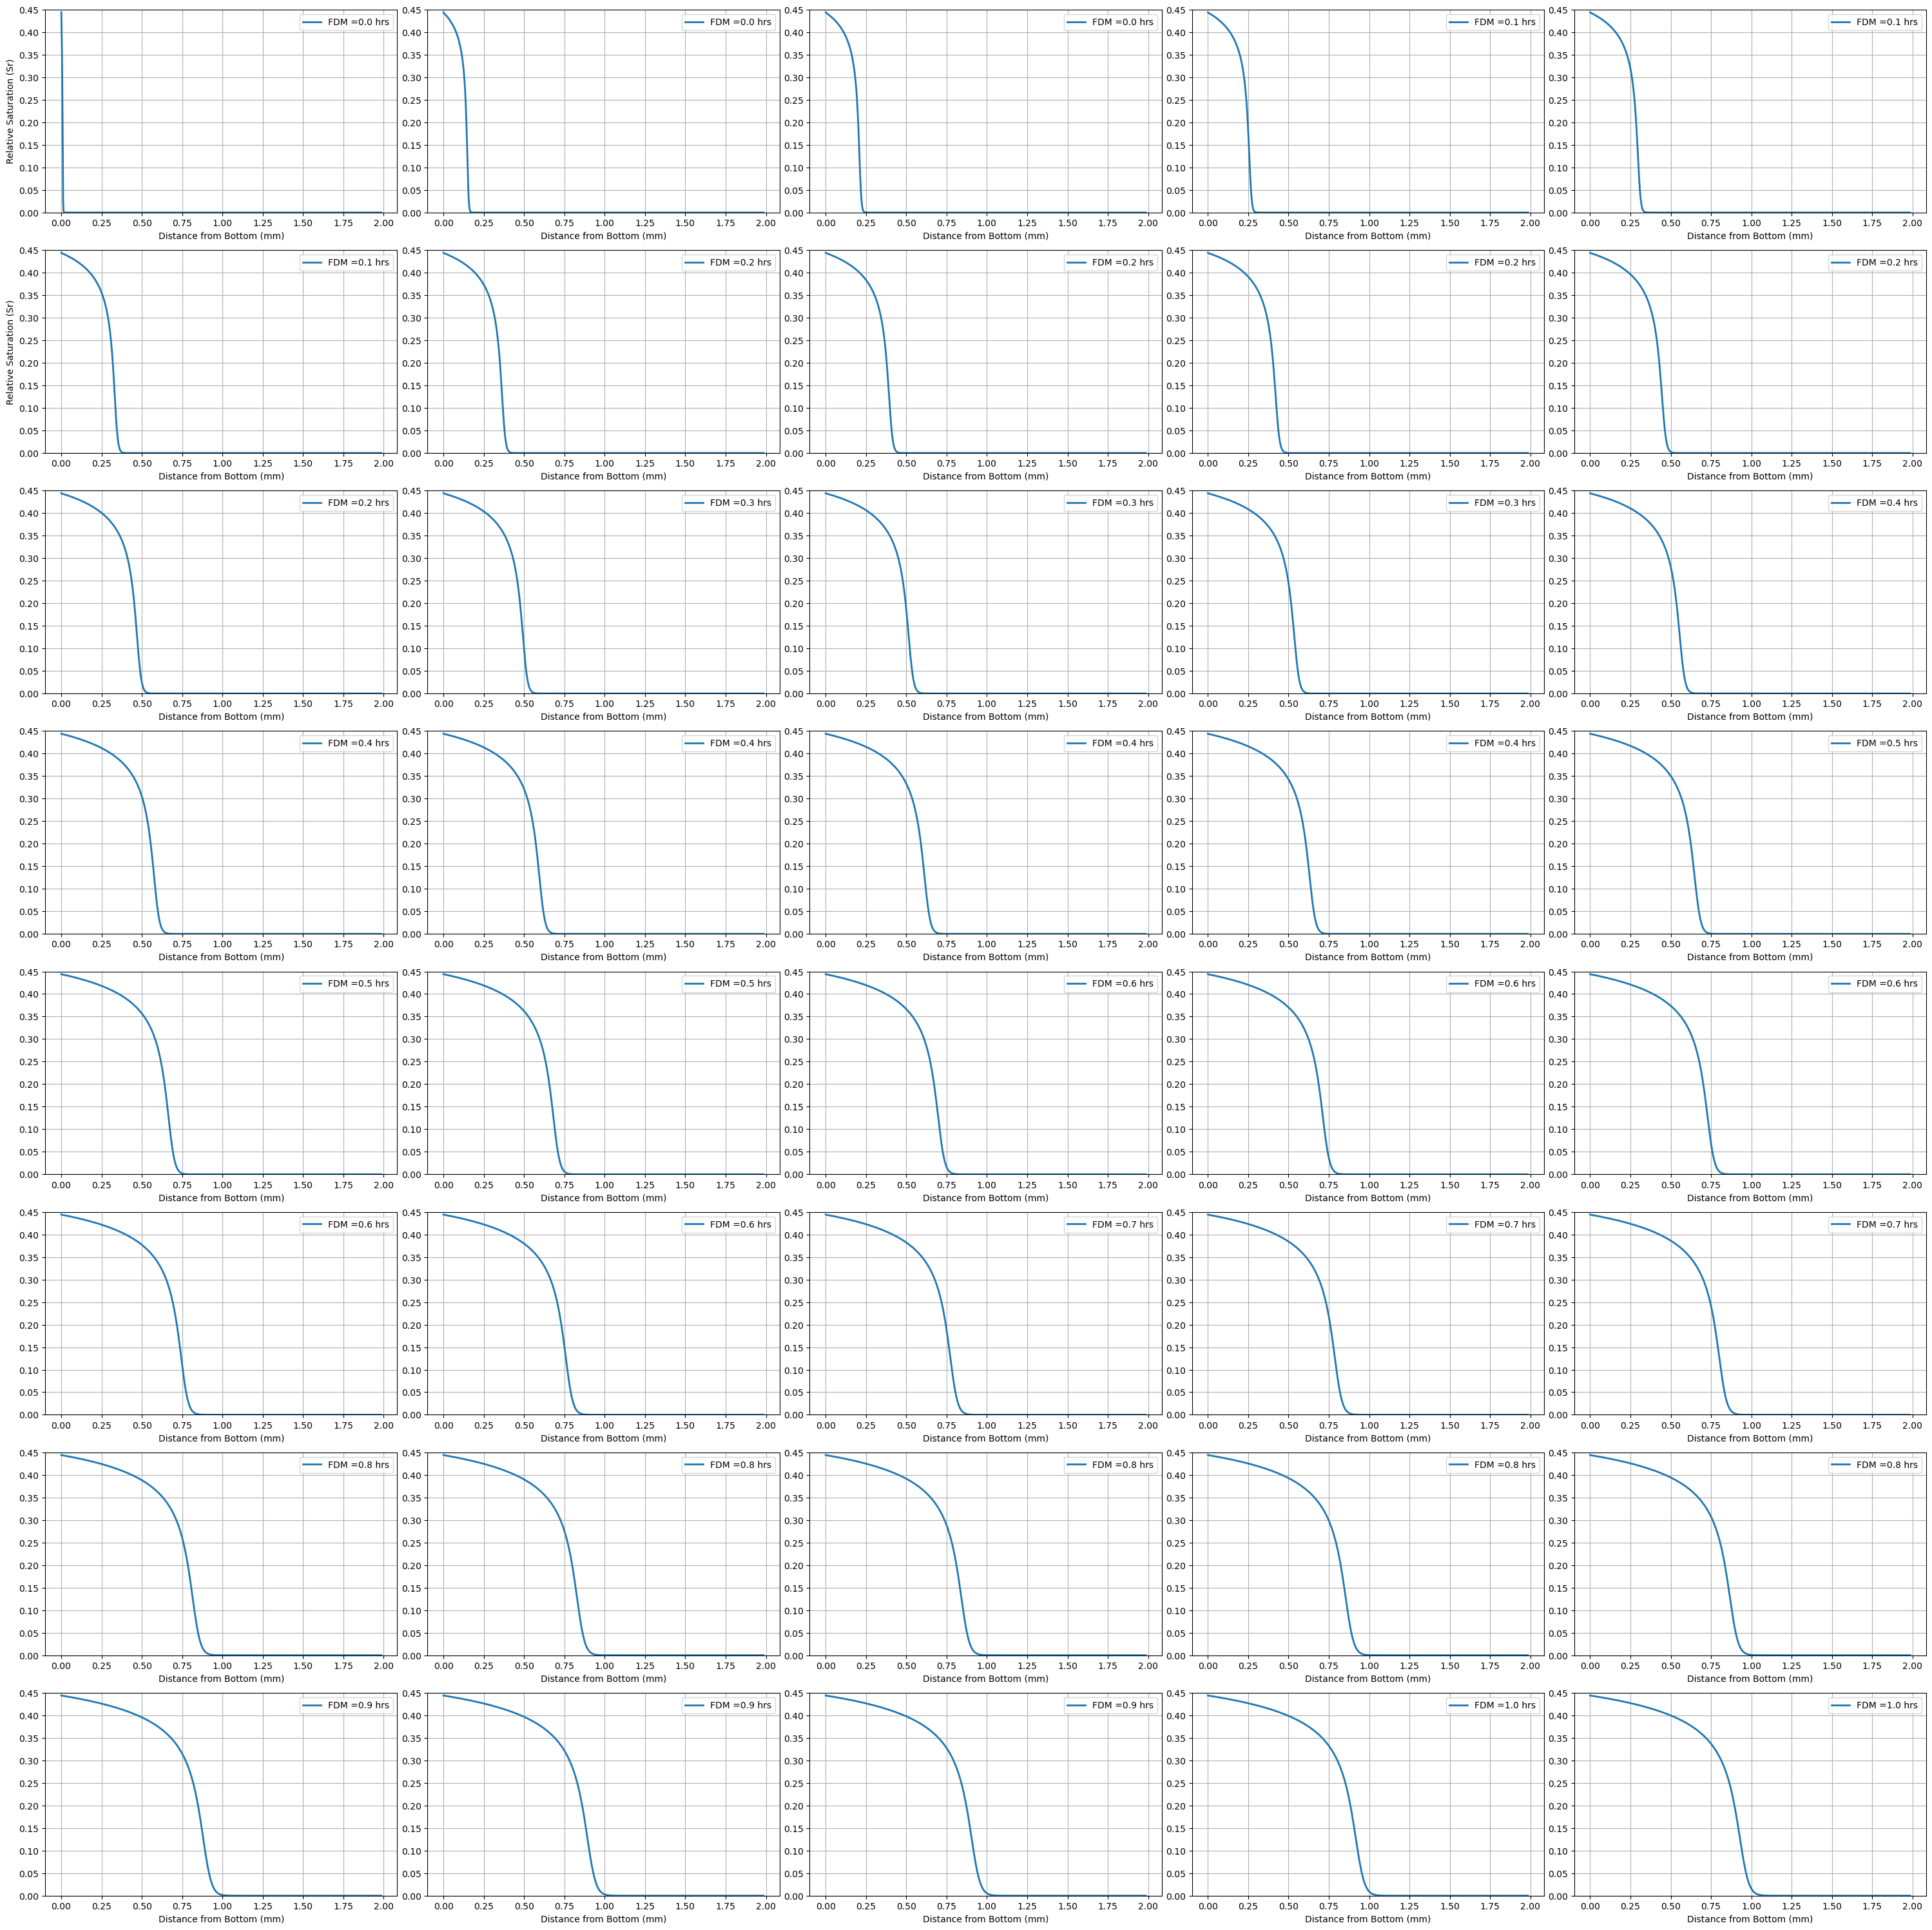

In [ ]:

fig, ax = plt.subplots(8, 5, figsize=(30, 30))

row = 0
column = 0
for count in np.arange(0,40):  

    if count==0:
        ax[row, column].plot(x_FDM, S_array[(count*250), :], linewidth=2, label=f'FDM ={count*250*0.0001} hrs')
        
    else:
        ax[row, column].plot(x_FDM, S_array[(count*250)-1, :], linewidth=2, label=f'FDM ={round(count*250*0.0001,1)} hrs')

        
    ax[row, column].set_xlabel('Distance from Bottom (mm)')
    ax[0, 0].set_ylabel('Relative Saturation (Sr)')
    ax[1, 0].set_ylabel('Relative Saturation (Sr)')
    #ax[row, column].set_xlim([-1, -0.9])
    ax[row, column].set_ylim([0, 0.45])
    ax[row, column].legend(loc='upper right')
    ax[row, column].grid(True)
    if (count + 1) % 5 == 0:  
        row += 1
        column = 0
    else:
        column += 1  

plt.tight_layout()
plt.show()